# Business Understanding

Jaya Jaya Institut menghadapi permasalahan tingginya angka dropout mahasiswa.
Hal ini berdampak pada kualitas pendidikan serta reputasi institusi.

## Permasalahan
- Banyak mahasiswa dropout
- Tidak ada sistem prediksi dini
- Sulit mengidentifikasi mahasiswa berisiko

## Tujuan
Membangun model machine learning untuk:
- Memprediksi risiko dropout mahasiswa
- Membantu institusi melakukan intervensi lebih awal

## Cakupan Proyek
- Data Understanding
- Data Preprocessing
- Modeling
- Evaluation
- Deployment (Streamlit)

## Import Library

Mengimpor library yang digunakan untuk analisis data, visualisasi, dan modeling.

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

## Import Library

Mengimpor library yang digunakan untuk analisis data, visualisasi, dan modeling.

In [34]:
# Load data
df = pd.read_csv("/content/drive/MyDrive/dicoding/dataset/data_siswa.csv", sep=';')

# Lihat data
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Menampilkan informasi dataset seperti tipe data dan jumlah kolom.

In [35]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Menampilkan Nama Kolom

Digunakan untuk memastikan struktur data sudah benar.

In [36]:
df.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

## Data Cleaning

Melakukan:
- Membersihkan nama kolom
- Mengubah nama kolom Status menjadi target

In [37]:
df.columns = df.columns.str.strip()
df.rename(columns={'Status': 'target'}, inplace=True)

## Filter Data Target

Menghapus data dengan status Enrolled agar model hanya fokus pada klasifikasi Dropout dan Graduate.

In [38]:
df = df[df['target'] != 'Enrolled']

df['target'] = df['target'].map({
    'Graduate': 0,
    'Dropout': 1
})

df['target'].value_counts()

,count
target,
0,2209
1,1421


## Exploratory Data Analysis

Melihat distribusi target setelah data dibersihkan.

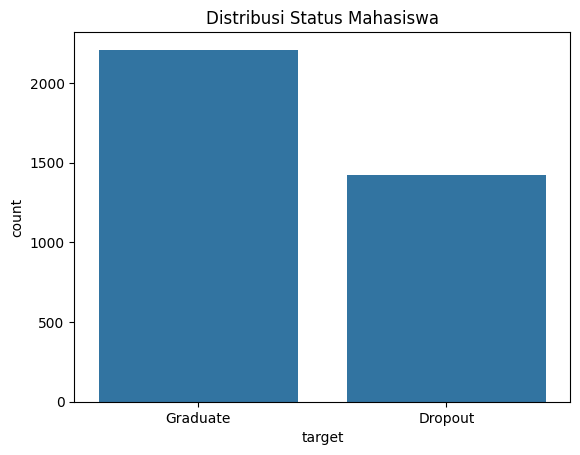

In [39]:
sns.countplot(x='target', data=df)
plt.title("Distribusi Status Mahasiswa")
plt.xticks([0,1], ['Graduate', 'Dropout'])
plt.show()

## Korelasi Antar Fitur

Melihat hubungan antar variabel menggunakan heatmap.

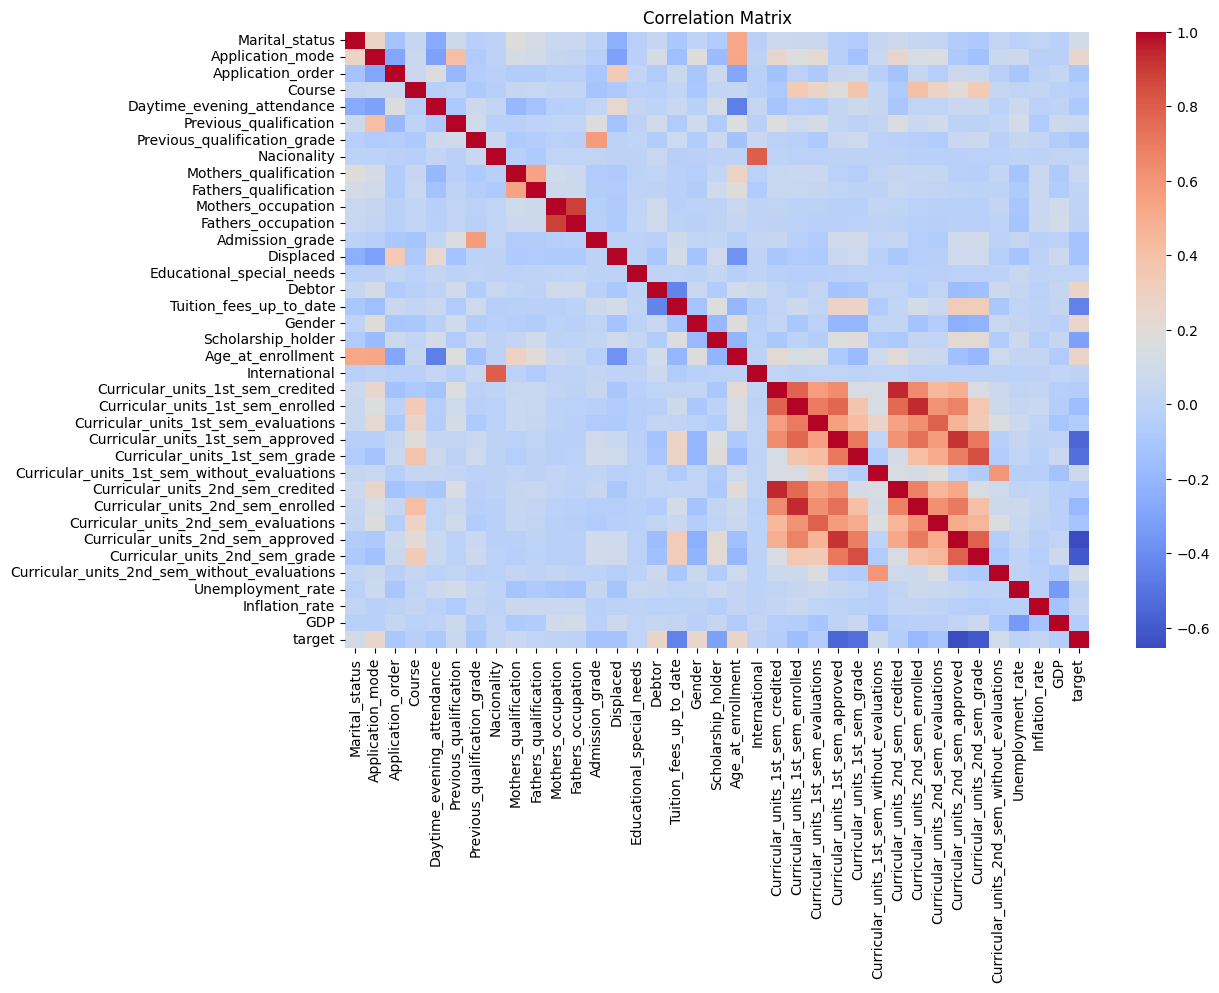

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Data Preprocessing

Memisahkan fitur dan target, serta melakukan scaling.

In [41]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

Menggunakan Random Forest untuk klasifikasi.

In [42]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## Evaluasi Model

Mengukur performa model menggunakan accuracy dan classification report.

In [43]:
y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9022038567493113

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       449
           1       0.91      0.82      0.87       277

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



## Confusion Matrix

Menampilkan hasil prediksi model dalam bentuk matriks.

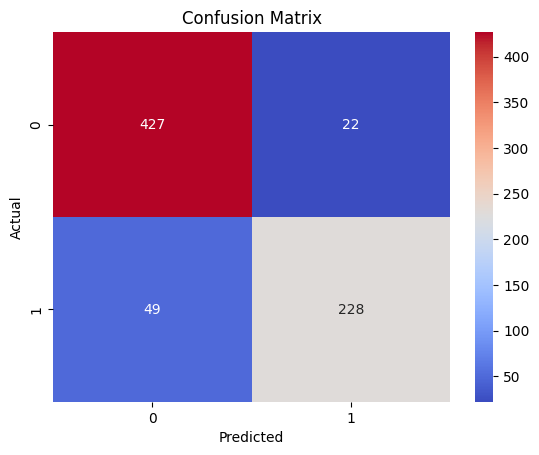

In [44]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

Menentukan fitur yang paling berpengaruh terhadap prediksi dropout.

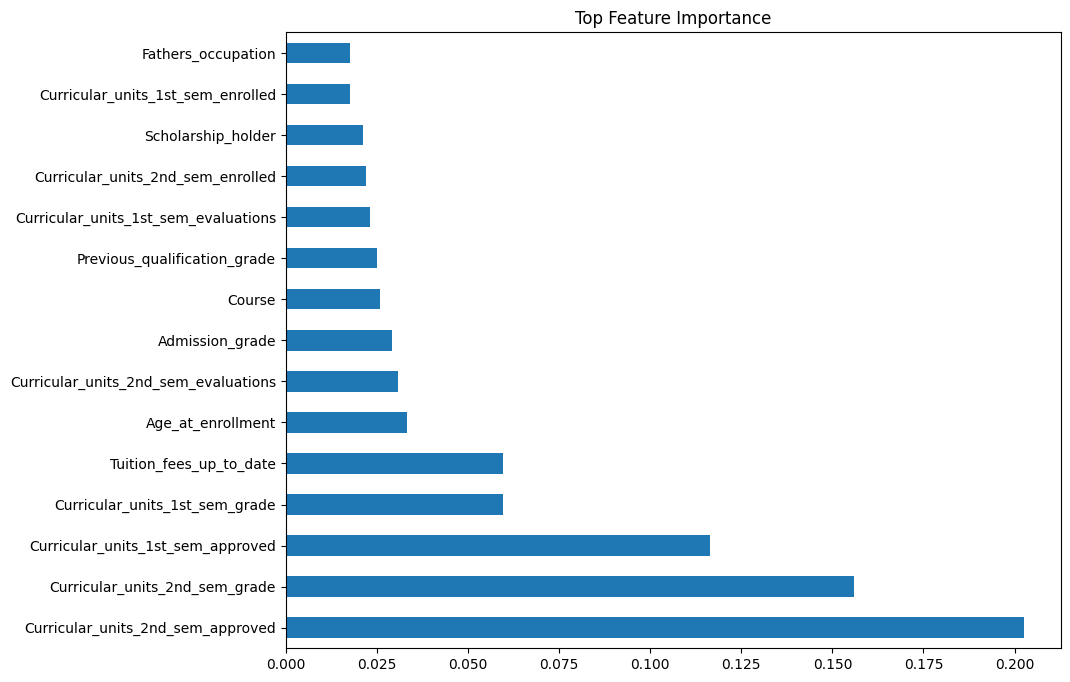

In [45]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,8))
feat_imp.head(15).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

## Save Model

Model disimpan untuk digunakan pada aplikasi Streamlit.

In [46]:
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

## Conclusion

Model mampu memprediksi dropout dengan baik.

Faktor utama:
- Performa akademik
- Nilai masuk
- Status pembayaran

## Action Items

1. Monitoring mahasiswa sejak semester awal  
2. Implementasi early warning system  
3. Program mentoring mahasiswa berisiko  
4. Evaluasi kondisi finansial mahasiswa  